In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from numpy.random import seed

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'CPU'
print(f"Running on: {device.upper()}")

Running on: CUDA


In [ ]:
iris = load_iris()
X = iris.data
y=iris.target
CLASS_NAMES = iris.target_names

In [ ]:
print(f"X shape : {X.shape}  →  {X.shape[0]} samples, {X.shape[1]} features")
print(f"Classes : {list(CLASS_NAMES)}")
print()

X shape : (150, 4)  →  150 samples, 4 features
Classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]



In [ ]:
print("Class Distribution:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  Class {i} ({name}) : {np.sum(y == i)} samples")
print()

Class Distribution:
  Class 0 (setosa) : 50 samples
  Class 1 (versicolor) : 50 samples
  Class 2 (virginica) : 50 samples



In [ ]:
print(f"{'Feature':<25} {'Min':>5}  {'Max':>5}")
print("-" * 38)
for i, name in enumerate(iris.feature_names):
    print(f"{name:<25} {X[:,i].min():>5.1f}  {X[:,i].max():>5.1f}")

Feature                     Min    Max
--------------------------------------
sepal length (cm)           4.3    7.9
sepal width (cm)            2.0    4.4
petal length (cm)           1.0    6.9
petal width (cm)            0.1    2.5


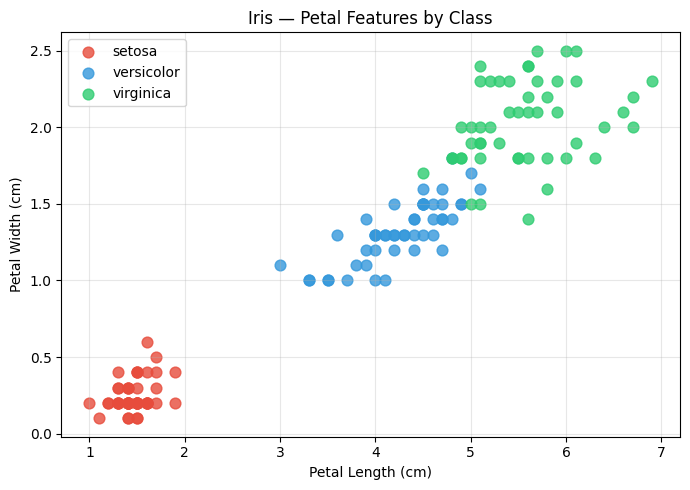

In [ ]:
COLORS = ['#e74c3c', '#3498db', '#2ecc71']
fig, ax = plt.subplots(figsize=(7, 5))

for i, name in enumerate(CLASS_NAMES):
    mask = (y == i)
    ax.scatter(X[mask, 2], X[mask, 3], c=COLORS[i], label=name, s=60, alpha=0.8)

ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Iris — Petal Features by Class')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train : {X_train.shape}  ({len(X_train)} samples)")
print(f"Test  : {X_test.shape}   ({len(X_test)} samples)")
print()

Train : (120, 4)  (120 samples)
Test  : (30, 4)   (30 samples)



In [ ]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"After scaling — Train mean : {X_train.mean(axis=0).round(2)}  (should be ≈ 0)")
print(f"After scaling — Train std  : {X_train.std(axis=0).round(2)}   (should be ≈ 1)")
print()

After scaling — Train mean : [-0. -0.  0.  0.]  (should be ≈ 0)
After scaling — Train std  : [1. 1. 1. 1.]   (should be ≈ 1)



In [ ]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

print(f"X_train_t : {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"y_train_t : {y_train_t.shape}   dtype={y_train_t.dtype}  ← must be long for CrossEntropyLoss")

X_train_t : torch.Size([120, 4])  dtype=torch.float32
y_train_t : torch.Size([120])   dtype=torch.int64  ← must be long for CrossEntropyLoss


In [ ]:
class IrisNet(nn.Module):
  def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(4, 16)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(16, 3)

  def forward(self, x):
      x = self.layer1(x)
      x = self.relu(x)
      x = self.layer2(x)
      return x

model = IrisNet().to(device)
print(model)
print()

IrisNet(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)



In [ ]:
total = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total}")

Total trainable parameters: 131


In [ ]:
with torch.no_grad():
    dummy_out = model(torch.randn(5, 4).to(device))
print(f"\nDummy forward pass: input (5, 4) → output {tuple(dummy_out.shape)}")


Dummy forward pass: input (5, 4) → output (5, 3)


In [ ]:
import math

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

model.eval()
with torch.no_grad():
    init_loss = loss_fn(model(X_train_t.to(device)), y_train_t.to(device))
print(f"Initial loss: {init_loss.item():.4f}   (expected ≈ {math.log(3):.4f})")
print()

Initial loss: 1.0461   (expected ≈ 1.0986)



In [ ]:
EPOCHS = 100
train_losses = []

for epoch in range(1, EPOCHS + 1):

    model.train()
    logits = model(X_train_t.to(device))
    loss = loss_fn(logits, y_train_t.to(device))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS}  |  Loss: {loss.item():.4f}")

Epoch  20/100  |  Loss: 0.3695
Epoch  40/100  |  Loss: 0.1923
Epoch  60/100  |  Loss: 0.1063
Epoch  80/100  |  Loss: 0.0724
Epoch 100/100  |  Loss: 0.0590


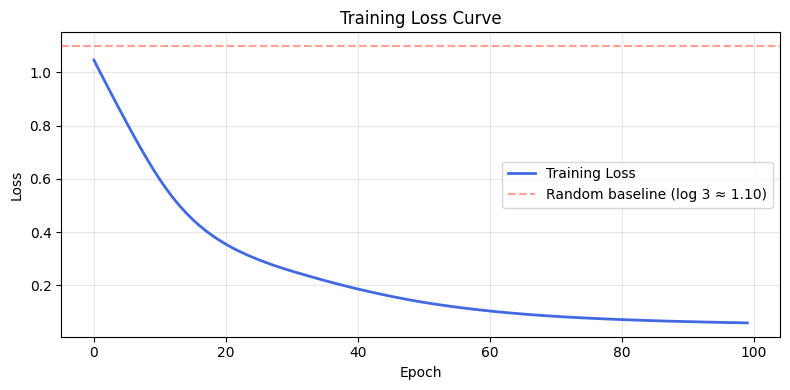

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='royalblue', lw=2, label='Training Loss')
plt.axhline(y=math.log(3), color='tomato', linestyle='--', alpha=0.6,
            label=f'Random baseline (log 3 ≈ {math.log(3):.2f})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t.to(device))
    predictions = torch.argmax(test_logits, dim=1)

predictions_np = predictions.cpu().numpy()

correct  = (predictions_np == y_test).sum()
accuracy = correct / len(y_test)

print(f"Test Accuracy: {correct}/{len(y_test)} = {accuracy:.1%}")
print()

Test Accuracy: 29/30 = 96.7%



In [ ]:
print("Per-class accuracy:")
for i, name in enumerate(CLASS_NAMES):
    mask    = (y_test == i)
    cls_acc = (predictions_np[mask] == i).mean()
    print(f"  {name:<12} : {cls_acc:.0%}  ({mask.sum()} test samples)")

Per-class accuracy:
  setosa       : 100%  (10 test samples)
  versicolor   : 90%  (10 test samples)
  virginica    : 100%  (10 test samples)


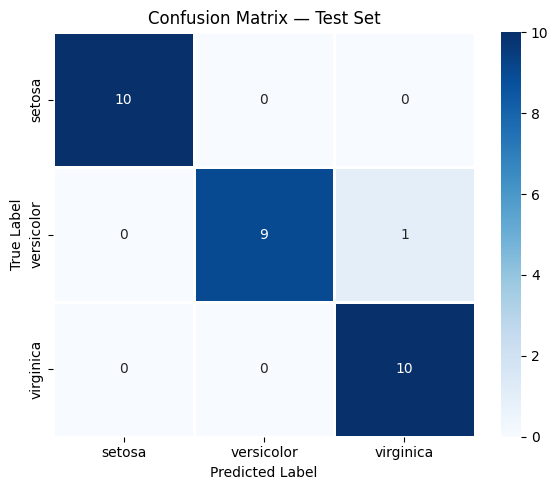

In [ ]:
cm = confusion_matrix(y_test, predictions_np)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=1, linecolor='white')
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()